> 本文件尝试复现 Chinchilla 论文中的部分 scaling laws（规模定律）结果。虽然无法做到数值完全一致，但仍可作为估算算力最优（compute-optimal）模型规模的实用参考。同时也包含了一些用于计算**参数量（parameters）和FLOPs（浮点运算量）**的工具函数。

## 环境 && 依赖

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

## Parameters 计算

### GPT参数量计算

In [2]:
def gpt_params(seq_len, vocab_size, d_model, num_heads, num_layers):
    """给定 GPT 配置，计算模型总参数量"""
    ffw_size = 4 * d_model # GPT 中前馈网络中间层维度恒为 4*d_model
    # token embedding 与 position embedding
    embeddings = d_model * vocab_size + d_model * seq_len
    # Transformer block
    attention = 3 * d_model**2 + 3 * d_model # QKV 权重与 bias
    attproj = d_model**2 + d_model
    ffw = d_model * ffw_size + ffw_size
    ffwproj = ffw_size * d_model + d_model
    layernorms = 2 * 2 * d_model
    # 最终 LayerNorm
    ln_f = 2 * d_model
    # 输出 projection（无 bias）
    dense = d_model * vocab_size
    # 注意：embedding 参数不计入总参数量
    total_params = (
        num_layers * (attention + attproj + ffw + ffwproj + layernorms)+ ln_f + dense
    )
    return total_params

In [5]:
gpt2 = dict(seq_len=1024, vocab_size=50257, d_model=768, num_heads=12, num_layers=12)
print( gpt_params(**gpt2) / 1e6 , "M parameters")  # 124M parameters

123.653376 M parameters


结果约为 123.65M，与 OpenAI 官方公布的 124M 参数基本一致

### Chinchilla 参数量计算

Chinchilla 与 GPT 的主要区别在于：

* 使用相对位置编码（relative positional embeddings）

* 前馈网络维度 ffw_size 不固定为 4*d_model

In [6]:
def chinchilla_params(seq_len, vocab_size, d_model, num_heads, num_layers, ffw_size):
    """Chinchilla 模型参数量计算（使用相对位置编码）"""
    # token embedding
    embeddings = d_model * vocab_size
    # Transformer block
    attention = 3 * d_model**2 + 3 * d_model
    relative_pos = d_model**2 + 2 * d_model # 相对位置相关参数
    attproj = d_model**2 + d_model
    ffw = d_model * ffw_size + ffw_size
    ffwproj = ffw_size * d_model + d_model
    layernorms = 2 * 2 * d_model
    # 最终 LayerNorm
    ln_f = 2 * d_model
    dense = d_model * vocab_size
    # 注意：embedding 参数未计入
    total_params = (
        num_layers * (attention + relative_pos + attproj + ffw + ffwproj + layernorms)+ ln_f + dense
    )
    return total_params

In [7]:
# Load in all the 50 Chinchilla models on the last page of the paper
import json

chinchilla_models_txt = '[[44000000.0, 512, 2048, 64, 8, 8], [57000000.0, 576, 2304, 64, 9, 9], [74000000.0, 640, 2560, 64, 10, 10], [90000000.0, 640, 2560, 64, 10, 13], [106000000.0, 640, 2560, 64, 10, 16], [117000000.0, 768, 3072, 64, 12, 12], [140000000.0, 768, 3072, 64, 12, 15], [163000000.0, 768, 3072, 64, 12, 18], [175000000.0, 896, 3584, 64, 14, 14], [196000000.0, 896, 3584, 64, 14, 16], [217000000.0, 896, 3584, 64, 14, 18], [251000000.0, 1024, 4096, 64, 16, 16], [278000000.0, 1024, 4096, 64, 16, 18], [306000000.0, 1024, 4096, 64, 16, 20], [425000000.0, 1280, 5120, 128, 10, 18], [489000000.0, 1280, 5120, 128, 10, 21], [509000000.0, 1408, 5632, 128, 11, 18], [552000000.0, 1280, 5120, 128, 10, 24], [587000000.0, 1408, 5632, 128, 11, 21], [632000000.0, 1536, 6144, 128, 12, 19], [664000000.0, 1408, 5632, 128, 11, 24], [724000000.0, 1536, 6144, 128, 12, 22], [816000000.0, 1536, 6144, 128, 12, 25], [893000000.0, 1792, 7168, 128, 14, 20], [1018000000.0, 1792, 7168, 128, 14, 23], [1143000000.0, 1792, 7168, 128, 14, 26], [1266000000.0, 2048, 8192, 128, 16, 22], [1424000000.0, 2176, 8704, 128, 17, 22], [1429000000.0, 2048, 8192, 128, 16, 25], [1593000000.0, 2048, 8192, 128, 16, 28], [1609000000.0, 2176, 8704, 128, 17, 25], [1731000000.0, 2304, 9216, 128, 18, 24], [1794000000.0, 2176, 8704, 128, 17, 28], [2007000000.0, 2304, 9216, 128, 18, 28], [2283000000.0, 2304, 9216, 128, 18, 32], [2298000000.0, 2560, 10240, 128, 20, 26], [2639000000.0, 2560, 10240, 128, 20, 30], [2980000000.0, 2560, 10240, 128, 20, 34], [3530000000.0, 2688, 10752, 128, 22, 36], [3802000000.0, 2816, 11264, 128, 22, 36], [4084000000.0, 2944, 11776, 128, 22, 36], [4516000000.0, 3072, 12288, 128, 24, 36], [6796000000.0, 3584, 14336, 128, 28, 40], [9293000000.0, 4096, 16384, 128, 32, 42], [11452000000.0, 4352, 17408, 128, 32, 47], [12295000000.0, 4608, 18432, 128, 36, 44], [12569000000.0, 4608, 18432, 128, 32, 47], [13735000000.0, 4864, 19456, 128, 32, 47], [14940000000.0, 4992, 19968, 128, 32, 49], [16183000000.0, 5120, 20480, 128, 40, 47]]'
chilchilla_models = json.loads(chinchilla_models_txt) # all 50 models
# tuples of params, d_model, ffw_size, kv_size, n_heads, n_layers from Table A9

In [8]:
for m in chilchilla_models[-5:]: # only print last 5 models of the table
    p, d, f, k, h, l = m
    nparams = chinchilla_params(seq_len = 1024, vocab_size = 32000, d_model = d, num_heads = h, num_layers = l, ffw_size=f)
    print(f"our estimated params: {nparams/1e6:.4f}M, chinchilla params: {p/1e6:.4f}M, d_model: {d}, n_heads: {h}, n_layers: {l}")

our estimated params: 12296.1623M, chinchilla params: 12295.0000M, d_model: 4608, n_heads: 36, n_layers: 44
our estimated params: 13124.4826M, chinchilla params: 12569.0000M, d_model: 4608, n_heads: 32, n_layers: 47
our estimated params: 14614.4279M, chinchilla params: 13735.0000M, d_model: 4864, n_heads: 32, n_layers: 47
our estimated params: 16037.5039M, chinchilla params: 14940.0000M, d_model: 4992, n_heads: 32, n_layers: 49
our estimated params: 16184.4582M, chinchilla params: 16183.0000M, d_model: 5120, n_heads: 40, n_layers: 47


## FLOPs 计算

In [9]:
def chinchilla_flops(seq_len, vocab_size, d_model, num_heads, num_layers, ffw_size):
    """根据 Chinchilla 论文 Appendix F 计算训练 FLOPs"""
    key_size = d_model // num_heads


    # Attention FLOPs
    attention = 2 * 3 * seq_len * d_model * (key_size * num_heads)
    attlogits = 2 * seq_len * seq_len * (key_size * num_heads)
    attsoftmax = 3 * num_heads * seq_len * seq_len
    attvalue = 2 * seq_len * seq_len * (key_size * num_heads)
    attlinear = 2 * seq_len * (key_size * num_heads) * d_model
    att = attention + attlogits + attsoftmax + attvalue + attlinear


    # 前馈网络 FLOPs
    dense = 2 * seq_len * (d_model * ffw_size + d_model * ffw_size)


    # 论文中为复现 Table A4，不计 embedding 和 logits FLOPs
    forward_flops = num_layers * (att + dense)
    backward_flops = 2 * forward_flops
    total_flops = forward_flops + backward_flops


    return total_flops

In [ ]:

chilchilla_models_table4 = [
  [10, 640, 2560, 10, 64],
  [20, 1024, 4096, 16, 64],
  [24, 1280, 5120, 10, 128 ],
  [26, 1792, 7168, 14, 128 ],
  [28, 2048, 8192, 16, 128],
  [40,  3584, 14336, 28, 128]
]
rows = []
for num_layers, d_model, ffw_size, num_heads, _ in chilchilla_models_table4:

    args = dict(seq_len = 2048, vocab_size = 32000, d_model = d_model, 
                num_heads = num_heads, num_layers = num_layers, ffw_size=ffw_size)

    D = args['seq_len'] # dataset size (cancels anyway, for the purposes of the ratio calculation below)
    N = chinchilla_params(**args)
    F = chinchilla_flops(**args)

    approx_flops = 6*D*N # approximate flops
    chinch_flops = F * (float(D) / args['seq_len']) # exact flops according to Chinchilla paper calculations

    # first copy all keyvalues from args into out
    out = {k:v for k,v in args.items()}
    # then add the calculated values
    out['N/M'] = N / 1e6 
    out['F/B'] = F / 1e9
    out['approx_flops/B'] = approx_flops / 1e9
    out['chinch_flops/B'] = chinch_flops / 1e9
    out['ratio'] = chinch_flops / approx_flops
    rows.append(out)

# make a pandas dataframe from rows
df = pd.DataFrame(rows)
pd.options.display.float_format = '{:.2f}'.format
df

,seq_len,vocab_size,d_model,num_heads,num_layers,ffw_size,N/M,F/B,approx_flops/B,chinch_flops/B,ratio
0,2048,32000,640,10,10,2560,73.83,929.88,907.17,929.88,1.03
1,2048,32000,1024,16,20,4096,305.71,4135.25,3756.53,4135.25,1.10
2,2048,32000,1280,10,24,5120,552.60,7353.45,6790.40,7353.45,1.08
3,2048,32000,1792,14,26,7168,1143.45,14670.32,14050.76,14670.32,1.04
4,2048,32000,2048,16,28,8192,1593.13,20220.44,19576.34,20220.44,1.03
5,2048,32000,3584,28,40,14336,6796.27,83021.05,83512.62,83021.05,0.99


## Scaling Laws: Approach 3

Chinchilla 论文给出了如下损失函数：
$$
L(N, D) = A * N^{-\alpha} + B * D^{-\beta} + E
$$
其中 E = 1.69, A = 406.4, B = 410.7, α = 0.34, β = 0.28

In [13]:
def L(N, D):
    """Chinchilla 论文中的损失函数"""
    E = 1.69
    A = 406.4
    B = 410.7
    alpha = 0.34
    beta = 0.28
    loss = A * N**(-alpha) + B * D**(-beta) + E
    return loss

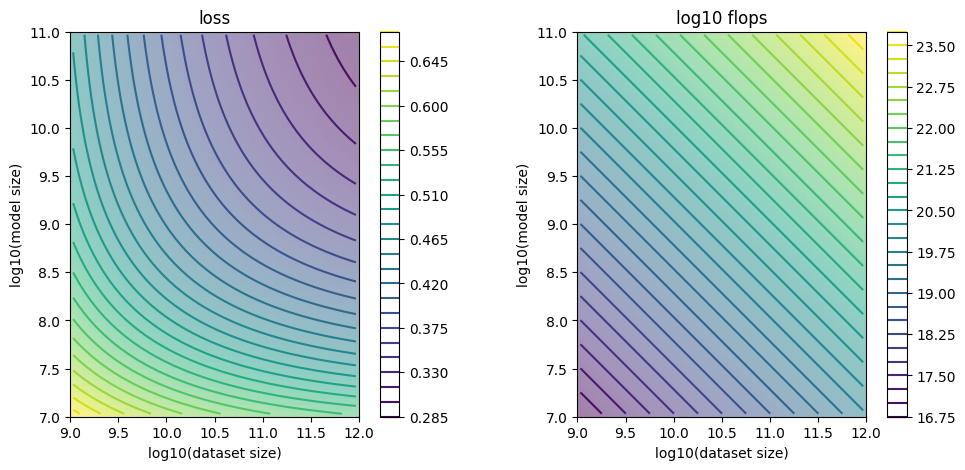

In [14]:
ns = 10 ** np.arange(7, 11, step=2**-4) # model sizes from 10M to 100B
ds = 10 ** np.arange(9, 12, step=2**-4) # dataset sizes from 1B to 1T
plt.figure(figsize=(12, 5))
plt.subplot(121)
# create a 2D countour plot of loss L as a function of model size and dataset size in ns,ds
loss2d = np.log10(np.array([[L(n, d) for d in ds] for n in ns]))
plt.imshow(loss2d, extent=[9, 12, 7, 11], origin='lower', alpha=0.5)
plt.contour(loss2d, levels=30, extent=[9, 12, 7, 11], origin='lower')
plt.xlabel('log10(dataset size)')
plt.ylabel('log10(model size)')
plt.title('loss')
plt.colorbar()
# plot the compute for each point, which is a deterministic function: flops = 6*N*D
plt.subplot(122)
compute2d = np.log10(np.array([[6*n*d for d in ds] for n in ns]))
plt.imshow(compute2d, extent=[9, 12, 7, 11], origin='lower', alpha=0.5)
plt.contour(compute2d, levels=30, extent=[9, 12, 7, 11], origin='lower')
plt.xlabel('log10(dataset size)')
plt.ylabel('log10(model size)')
plt.title('log10 flops')
plt.colorbar()

给定任何 N,D，我们都可以估计两个方面：1）损失，和 2）总浮点运算次数。现在我们想解决以下问题：给定一个特定的浮点运算次数预算 C，找到：$$N_{opt}, D_{opt} = \argmin_{FLOPs(N,D) = C}L(N, D)$$ 
即，我们应该训练多大的模型，以及处理多少个 token？

best model size: 316.23M
best dataset size: 11.65B


Text(0, 0.5, 'loss')

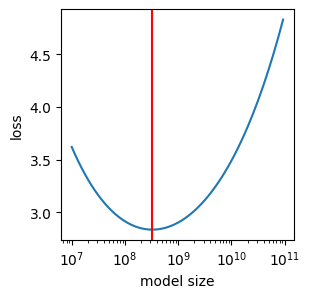

In [29]:
c = 2.21e19 # target compute budget (usually know this because we know how many GPU for how long go brrr)
# (I got this flop number from row 1 of Table A3)
# sweep model sizes from 10M to 100B
ns = 10 ** np.arange(7, 11, step=2**-5)
# using C = 6*N*D, solve for D that maintains the compute budget c
ds = c / (6 * ns)
# evaluate the loss in each case
losses = L(ns, ds)
# find the argmin
best = np.argmin(losses)
print(f"best model size: {ns[best]/1e6:.2f}M")
print(f"best dataset size: {ds[best]/1e9:.2f}B")
# plot the loss
plt.figure(figsize=(3,3))
plt.plot(ns, losses)
plt.xscale('log')
# plot a vertical bar at the best model size
plt.axvline(ns[best], color='red')
plt.xlabel('model size')
plt.ylabel('loss')

这种方式计算出来的结果与 Chinchilla 论文中的结果有些许歧义。

## Scaling Laws: Approach 2 

第二种方法：固定了一个失败的预算，并运行多个模型/数据集规模，测量损失，拟合一个抛物线，并找到最小值。因此，它是我们所追求目标的一个相当直接的测量方法。那么，计算给定模型规模下的计算最优 token 数量的最佳方式，例如，就是通过简单的插值。

In [30]:
raw = [
    [400e6, 7.7e9],
    [1e9, 20.0e9],
    [10e9, 219.5e9],
    [67e9, 1.7e12],
    [175e9, 4.3e12],
    [280e9, 7.1e12],
    [520e9, 13.4e12],
    [1e12, 26.5e12],
    [10e12, 292.0e12],
]

In [31]:
import numpy as np

x = np.array([np.log10(x[0]) for x in raw])
y = np.array([np.log10(x[1]) for x in raw])
A = np.vstack([x, np.ones(len(x))]).T
m, c = np.linalg.lstsq(A, y, rcond=None)[0]
print(f"y = {m}x + {c}")

y = 1.0409573169995878x + 0.9353887152390967


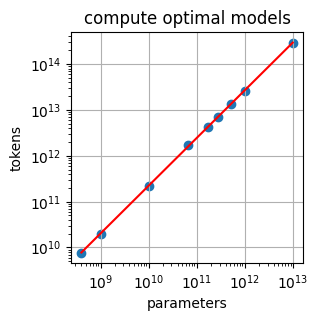

In [32]:
plt.figure(figsize=(3, 3))
# plot the line
plt.plot([q[0] for q in raw], [10**(m*np.log10(q[0]) + c) for q in raw], label='linear regression', color='r')
# plot the raw data
plt.scatter([q[0] for q in raw], [q[1] for q in raw], label='raw data')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('parameters')
plt.ylabel('tokens')
plt.title('compute optimal models')
plt.grid()

In [34]:
xquery = 124e6 # query model size here (e.g. GPT-2 small is 124M)
yquery = 10**(m*np.log10(xquery) + c)
print(f"predicted parameters for {xquery/1e6:.2f}M tokens: {yquery/1e9:.2f}B")

predicted parameters for 124.00M tokens: 2.29B
